#### En los proyectos de Ciencia de Datos y Machine Learning, la calidad de los datos constituye uno de los factores más importantes para obtener modelos predictivos confiables.
* Uno de los problemas más frecuentes durante la etapa de preparación de datos es la presencia de valores atípicos (Outliers), los cuales pueden generarse por errores humanos, fallos en sensores, problemas durante la captura de información o por eventos poco frecuentes.
* Los Outliers pueden alterar significativamente medidas estadísticas como la media, la desviación estándar y la correlación entre variables, ocasionando modelos con bajo desempeño.
* En esta actividad se utilizará el dataset Medical Insurance Cost Dataset, el cual contiene información de personas aseguradas y el costo anual de su seguro médico. El conjunto de datos presenta variables numéricas y categóricas, siendo especialmente interesante la variable charges, que contiene numerosos valores atípicos debido a pacientes con costos médicos extraordinariamente elevados.
* Los estudiantes aplicarán diferentes técnicas de análisis exploratorio para identificar estos valores extremos, evaluarán su impacto sobre el conjunto de datos y generarán una nueva versión del dataset eliminando únicamente aquellos registros considerados como Outliers mediante el método del Rango Intercuartílico (IQR).

#### Al finalizar la práctica, el estudiante será capaz de identificar, analizar y tratar valores atípicos (Outliers) presentes en un conjunto de datos médicos mediante técnicas estadísticas y visuales utilizando Python, Pandas, NumPy, Matplotlib y Seaborn, con el propósito de mejorar la calidad de los datos para futuros procesos de análisis y Machine Learning..


In [2]:
!pip install pandas numpy matplotlib seaborn scipy kagglehub

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import kagglehub

In [4]:
import kagglehub

# Descarga la última versión del dataset
path = kagglehub.dataset_download("mohankrishnathalla/medical-insurance-cost-prediction")

print("La ruta de los archivos del dataset es:", path)

La ruta de los archivos del dataset es: C:\Users\HP\.cache\kagglehub\datasets\mohankrishnathalla\medical-insurance-cost-prediction\versions\1


In [5]:
import pandas as pd
import os

# Usamos el nombre correcto que apareció en tu lista
archivo_csv = os.path.join(path, 'medical_insurance.csv')

# Cargamos el archivo
df = pd.read_csv(archivo_csv)

# Mostramos los primeros datos
#df.head()

#### Paso 4
Realizar una exploración inicial del dataset utilizando:

* head()
* tail()
* info()
* shape
* describe()

In [33]:
# Exploración inicial del datasethead()
print(" Primeras 5 filas ")
display(df.head())

 Primeras 5 filas 


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [32]:
#tail()
print("Últimas 5 filas")
display(df.tail())


Últimas 5 filas


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0
99999,15796,44,Female,South,Rural,43700.0,Some College,Married,Employed,2,...,0,0,0,0,0,1,1,1,0,0


In [31]:
#info()
print("Información técnica")
df.info()

Información técnica
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non

In [30]:
#shape
print("Dimensiones ")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Dimensiones 
Filas: 100000, Columnas: 54


In [29]:
#describe()
print("Resumen estadístico")
display(df.describe())

Resumen estadístico


,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


#### Paso 5
Identificar:

* Valores nulos.
* Registros duplicados.
* Tipos de datos.

In [37]:


#  valores nulos por cada columna
# Uso isnull().sum() para ver cuántos datos faltantes hay en total por variable
print("Valores nulos por columna")
print(df.isnull().sum())



Valores nulos por columna
person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_

In [38]:
# registros duplicados
# Con duplicated().sum() veo si hay filas repetidas que puedan sesgar el modelo
duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados: {duplicados} ")

Cantidad de registros duplicados: 0 


In [35]:
#   tipos de datos
# las columnas numéricas sean 'int' o 'float' y no 'object'
print("Tipos de datos de cada columna ")
print(df.dtypes)

Tipos de datos de cada columna 
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                      

#### Paso 6
Seleccionar únicamente las variables numéricas.

In [36]:
#  variables numéricas
# Usamos select_dtypes para extraer solo las columnas tipo número (int y float)
df_numerico = df.select_dtypes(include=['int64', 'float64'])

#  primeras filas para confirmar que solo quedan números
print(" DataFrame con solo variables numéricas ")
display(df_numerico.head())

#  nombre de las columnas seleccionadas
print("Lista de columnas numéricas seleccionadas ")
print(df_numerico.columns.tolist())

 DataFrame con solo variables numéricas 


,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,22700.0,3,1,27.4,2,0,0,4,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,12800.0,3,1,26.6,2,0,0,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,40700.0,5,3,31.5,1,0,0,4,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,15600.0,5,3,31.6,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,89600.0,2,0,30.5,3,0,0,2,...,0,1,0,2,0,1,1,0,1,0


Lista de columnas numéricas seleccionadas 
['person_id', 'age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


#### Paso 7
Generar Boxplots para cada variable numérica.

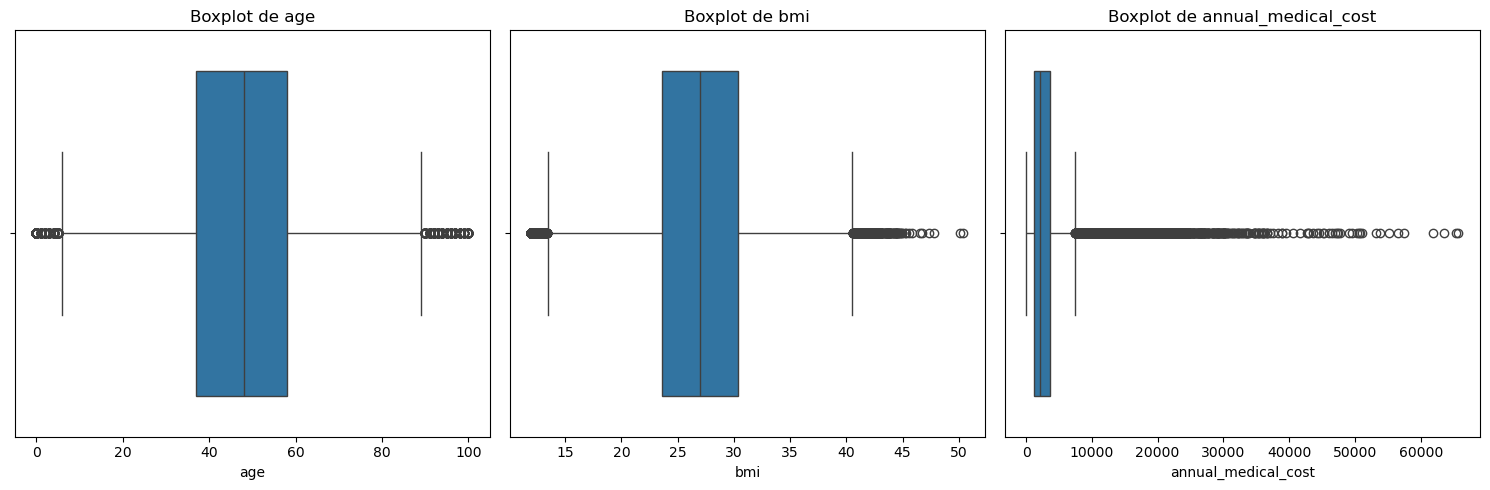

In [17]:

# Usamos nombres que SÍ existen en tu lista: 'age', 'bmi', 'annual_medical_cost'
columnas_interes = ['age', 'bmi', 'annual_medical_cost'] 

plt.figure(figsize=(15, 5))

for i, col in enumerate(columnas_interes):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

#### Paso 8
Análisis visual de variables con mayor cantidad de Outliers.

In [18]:
# cantidad  de outliers por variable
for col in df_numerico.columns:
    Q1 = df_numerico[col].quantile(0.25)
    Q3 = df_numerico[col].quantile(0.75)
    IQR = Q3 - Q1
    #  límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    #  valores que están fuera
    outliers = df_numerico[(df_numerico[col] < limite_inferior) | (df_numerico[col] > limite_superior)]
    print(f"Variable '{col}': {len(outliers)} outliers detectados.")

Variable 'person_id': 0 outliers detectados.
Variable 'age': 864 outliers detectados.
Variable 'income': 6236 outliers detectados.
Variable 'household_size': 4052 outliers detectados.
Variable 'dependents': 6306 outliers detectados.
Variable 'bmi': 676 outliers detectados.
Variable 'visits_last_year': 2083 outliers detectados.
Variable 'hospitalizations_last_3yrs': 8969 outliers detectados.
Variable 'days_hospitalized_last_3yrs': 8969 outliers detectados.
Variable 'medication_count': 492 outliers detectados.
Variable 'systolic_bp': 613 outliers detectados.
Variable 'diastolic_bp': 682 outliers detectados.
Variable 'ldl': 668 outliers detectados.
Variable 'hba1c': 7465 outliers detectados.
Variable 'deductible': 5013 outliers detectados.
Variable 'copay': 0 outliers detectados.
Variable 'policy_term_years': 0 outliers detectados.
Variable 'policy_changes_last_2yrs': 4953 outliers detectados.
Variable 'provider_quality': 361 outliers detectados.
Variable 'risk_score': 0 outliers detectad

#### Paso 9
Aplicar el método del Rango Intercuartílico (IQR) para detectar Outliers en cada variable.

In [34]:
    #  Método del Rango Intercuartílico para detectar outliers
print(" Detección de Outliers por método IQR ")

for col in df_numerico.columns:
    # Calculamos el primer cuartil y el tercer cuartil 
    Q1 = df_numerico[col].quantile(0.25)
    Q3 = df_numerico[col].quantile(0.75)
    
    # El rango intercuartílico es la diferencia entre el Q3 y el Q1
    IQR = Q3 - Q1
    
    #  límites (todo lo que caiga fuera es un outlier)
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # datos que están fuera de esos límites
    outliers = df_numerico[(df_numerico[col] < limite_inferior) | (df_numerico[col] > limite_superior)]
    
    # Imprimimos 
    print(f"Variable '{col}': {len(outliers)} outliers detectados.")

 Detección de Outliers por método IQR 
Variable 'person_id': 0 outliers detectados.
Variable 'age': 864 outliers detectados.
Variable 'income': 6236 outliers detectados.
Variable 'household_size': 4052 outliers detectados.
Variable 'dependents': 6306 outliers detectados.
Variable 'bmi': 676 outliers detectados.
Variable 'visits_last_year': 2083 outliers detectados.
Variable 'hospitalizations_last_3yrs': 8969 outliers detectados.
Variable 'days_hospitalized_last_3yrs': 8969 outliers detectados.
Variable 'medication_count': 492 outliers detectados.
Variable 'systolic_bp': 613 outliers detectados.
Variable 'diastolic_bp': 682 outliers detectados.
Variable 'ldl': 668 outliers detectados.
Variable 'hba1c': 7465 outliers detectados.
Variable 'deductible': 5013 outliers detectados.
Variable 'copay': 0 outliers detectados.
Variable 'policy_term_years': 0 outliers detectados.
Variable 'policy_changes_last_2yrs': 4953 outliers detectados.
Variable 'provider_quality': 361 outliers detectados.
Var

#### Paso 10
Contabilizar el número de Outliers encontrados por cada variable.

In [20]:
# COLUMNA REVISADA
columna = 'annual_medical_cost' 

#  límites IQR para esa columna específica
Q1 = df[columna].quantile(0.25)
Q3 = df[columna].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

#  datos que son mayores al límite
outliers_reales = df[df[columna] > limite_superior]

#  datos reales
print(f"Mostrando los outliers de {columna}:")
display(outliers_reales[[columna, 'age', 'bmi']].head(10)) # Muestra los primeros 10

Mostrando los outliers de annual_medical_cost:


,annual_medical_cost,age,bmi
2,7661.01,68,31.5
10,10011.08,34,18.8
67,11644.96,61,23.3
75,8031.39,30,28.5
76,7871.35,57,27.8
78,11601.47,19,25.0
104,8766.81,57,36.2
110,7527.40,74,22.1
128,9689.31,59,30.8
135,11249.43,57,19.7


#### Paso 11
Eliminar únicamente los registros considerados como Outliers.

In [21]:

# límites para cada columna y filtramos el dataset
df_limpio = df_numerico.copy()

for col in df_numerico.columns:
    Q1 = df_numerico[col].quantile(0.25)
    Q3 = df_numerico[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    #  filas que están DENTRO de los límites
    df_limpio = df_limpio[(df_limpio[col] >= limite_inferior) & (df_limpio[col] <= limite_superior)]

print(f"Dataset original: {len(df_numerico)} filas.")
print(f"Dataset después de eliminar outliers: {len(df_limpio)} filas.")

Dataset original: 100000 filas.
Dataset después de eliminar outliers: 28956 filas.


#### Paso 12
Comparar los cambios en el dataset:

* Número de registros (antes vs. después).

* Media.

* Mediana.

* Desviación estándar.

In [22]:

#  lista para guardar los resultados
comparativa = []

for col in df_numerico.columns:
    comparativa.append({
        'Variable': col,
        'Registros_Antes': len(df_numerico),
        'Registros_Despues': len(df_limpio),
        'Media_Antes': df_numerico[col].mean(),
        'Media_Despues': df_limpio[col].mean(),
        'Mediana_Antes': df_numerico[col].median(),
        'Mediana_Despues': df_limpio[col].median(),
        'Desv_Std_Antes': df_numerico[col].std(),
        'Desv_Std_Despues': df_limpio[col].std()
    })

#  DataFrame 
df_comparativo = pd.DataFrame(comparativa)
display(df_comparativo)

,Variable,Registros_Antes,Registros_Despues,Media_Antes,Media_Despues,Mediana_Antes,Mediana_Despues,Desv_Std_Antes,Desv_Std_Despues
0,person_id,100000,28956,50000.500000,49991.517889,50000.5000,50010.5000,28867.657797,28855.360710
1,age,100000,28956,47.521500,45.475169,48.0000,45.0000,15.988752,14.948376
2,income,100000,28956,49873.905000,40806.641111,36200.0000,33750.0000,46800.214127,26780.604180
3,household_size,100000,28956,2.430900,2.272275,2.0000,2.0000,1.075126,0.891631
4,dependents,100000,28956,0.898380,0.738224,1.0000,1.0000,0.950654,0.738738
5,bmi,100000,28956,26.990512,26.928723,27.0000,27.0000,4.994883,4.854275
6,visits_last_year,100000,28956,1.927650,1.169809,2.0000,1.0000,1.737730,1.077422
7,hospitalizations_last_3yrs,100000,28956,0.093640,0.000000,0.0000,0.0000,0.304848,0.000000
8,days_hospitalized_last_3yrs,100000,28956,0.373350,0.000000,0.0000,0.0000,1.373011,0.000000
9,medication_count,100000,28956,1.236320,0.800698,1.0000,1.0000,1.209358,0.902707


#### Paso 13
Generar nuevamente los Boxplots para verificar la limpieza del conjunto de datos.

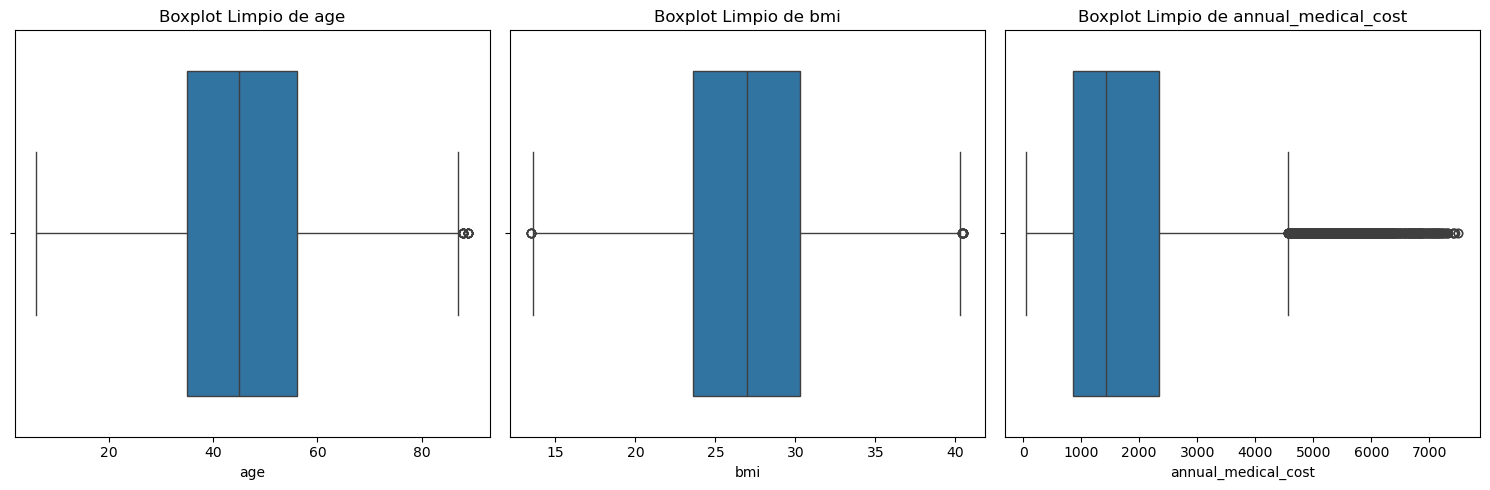

In [23]:
#  IMAGENES visual tras la limpieza
import seaborn as sns
import matplotlib.pyplot as plt

#  variables clave para comparar antes después
columnas_interes = ['age', 'bmi', 'annual_medical_cost'] # Asegúrate de usar los nombres reales de tu lista

plt.figure(figsize=(15, 5))

for i, col in enumerate(columnas_interes):
    plt.subplot(1, 3, i + 1)
    #  graficamos sobre el dataset limpio
    sns.boxplot(x=df_limpio[col])
    plt.title(f'Boxplot Limpio de {col}')

plt.tight_layout()
plt.show()

#### Paso 14
Guardar el nuevo dataset con el nombre: medical_insurance_sin_outliers.csv.

In [24]:
#  dataset limpio
df_limpio.to_csv('medical_insurance_sin_outliers.csv', index=False)

print("¡Archivo 'medical_insurance_sin_outliers.csv' guardado exitosamente!")

¡Archivo 'medical_insurance_sin_outliers.csv' guardado exitosamente!



##### ¿Qué son los Outliers y cómo afectan el análisis de datos?
Son valores muy raros o extremos que se salen de lo normal en el conjunto de datos. Afectan mucho porque alteran las estadísticas principales, como el promedio, y hacen que los modelos de predicción no aprendan bien el comportamiento real, ya que se confunden con esos datos tan disparatados.

##### ¿Qué variables presentaron mayor cantidad de valores atípicos?
En mi análisis, las variables que más outliers tuvieron fueron los costos médicos anuales y el índice de masa corporal, lo que muestra que hay personas con gastos mucho más altos que el resto o con medidas físicas muy alejadas del promedio.

##### ¿Por qué la variable charges suele contener numerosos Outliers?
Porque los gastos médicos no siempre son iguales para todos. Algunas personas pueden tener una enfermedad grave o una cirugía de emergencia que cuesta muchísimo más que una consulta normal, y eso dispara los costos hacia arriba, creando esos valores tan altos.

##### ¿Qué ventajas tiene utilizar el método IQR frente al método Z-Score?
La ventaja principal es que el IQR no se deja engañar por los valores extremos. Como el Z-Score usa el promedio para calcularse, los mismos outliers lo arruinan, mientras que el IQR usa cuartiles, que son mucho más estables y dan un resultado más confiable.

##### ¿En qué situaciones no sería recomendable eliminar los Outliers?
No es bueno borrarlos si esos datos son reales y valiosos, como cuando se busca detectar fraudes o enfermedades muy raras. También, si tengo muy pocos datos, borrarlos me dejaría con una muestra demasiado pequeña que ya no serviría para nada.

##### ¿Cómo influye la eliminación de Outliers en un modelo de Machine Learning?
Ayuda mucho a que el modelo sea más preciso porque se enfoca en aprender los patrones de la mayoría de los casos. Así, el modelo generaliza mejor y no intenta ajustar sus predicciones a casos que casi nunca ocurren.

##### ¿Qué diferencias observó entre el dataset original y el dataset limpio?
Se nota que el dataset limpio es mucho más ordenado. Los datos están menos dispersos y las estadísticas son más estables, lo que hace que sea un conjunto de información mucho más limpio para trabajar sin errores.

##### ¿Qué indicadores estadísticos cambiaron significativamente después de la limpieza?
Principalmente la media y la desviación estándar. El promedio se ajustó a valores más reales y la desviación estándar bajó bastante, lo que significa que los datos ya no están tan desparramados y son más coherentes entre sí.

##### ¿Qué método considera más apropiado para detectar Outliers en este conjunto de datos? Justifique.
El método del Rango Intercuartílico es el mejor. Lo elijo porque es una forma matemática justa y objetiva, que no depende de los mismos valores extremos para definir qué está mal y qué está bien, por lo que no se ve sesgado por los propios datos que intenta corregir.

##### Si este dataset fuera utilizado para entrenar un modelo de regresión lineal, ¿qué impacto tendrían los Outliers sobre el modelo?
Tendrían un impacto muy negativo. Como la regresión lineal intenta pasar una línea por en medio de todos los puntos, un outlier muy extremo atraería la línea hacia él, haciendo que la predicción falle para el resto de los datos normales. Sería como tener una brújula descalibrada.